In [4]:
# Load the dataset -- given by the eda starter code
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from load import run

disaster_list = ["hurricane-matthew", "midwest-flooding", "socal-fire"]
data = run(disaster_list)

Loading train images and labels for hurricane-matthew dataset...
Loading train images and labels for midwest-flooding dataset...
Loading train images and labels for socal-fire dataset...


### Number Of Images Per Disaster

In [5]:
images_num = pd.DataFrame()
images_num["Disaster Dataset"] = disaster_list
images_num["Number of Images"] = [len(data[d]["images"]) for d in disaster_list]

display(images_num)


,Disaster Dataset,Number of Images
0,hurricane-matthew,200
1,midwest-flooding,200
2,socal-fire,200


### Image Sizes

In [6]:
sizes = []

for d in disaster_list:
    disaster_size = []
    for image in data[d]["images"]:

        green = image[:,:, 1]  #get one channel only
        mask = green > 0  #where there is no black pixels
        
        rows = np.any(mask, axis=1) #create tuple array of mask
        cols = np.any(mask, axis=0)

        top, bottom = np.where(rows)[0][[0, -1]] #apply tuple to image where first and last are T
        left, right = np.where(cols)[0][[0, -1]]

        cropped = green[top:bottom + 1, left:right + 1]  #reconstruct image as cropped
        disaster_size.append(cropped.size)

    sizes.append(disaster_size)

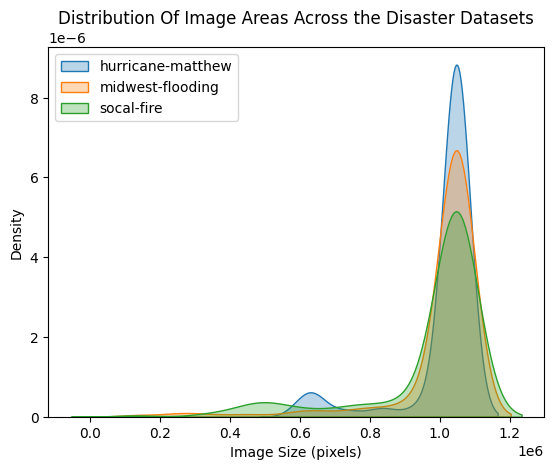

In [7]:
for i in range(3):
    sns.kdeplot(sizes[i], label=disaster_list[i], fill=True, alpha=0.3, )

plt.title("Distribution Of Image Areas Across the Disaster Datasets")
plt.xlabel("Image Size (pixels)")
plt.legend()
plt.show()


We analyzed the consistency of image dimensions across disasters to identify abnormalities which can cause bias in our program. From the graph, it is shown that most images are between 1.0 x 10^6 and 1.1 x 10^6. Most image sizes are consistent and for the ones that are not consistent we will be cropping the black parts and getting them to a similar dimension as the majority.

## Distribution of Damage Labels

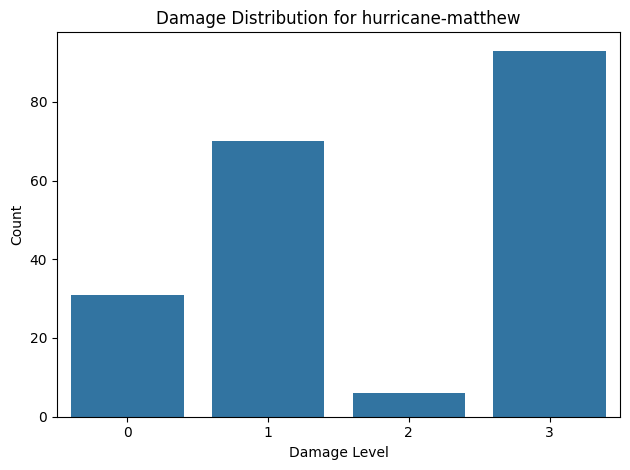

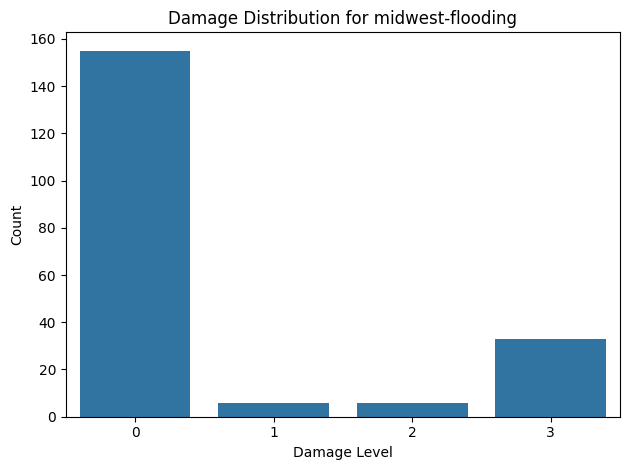

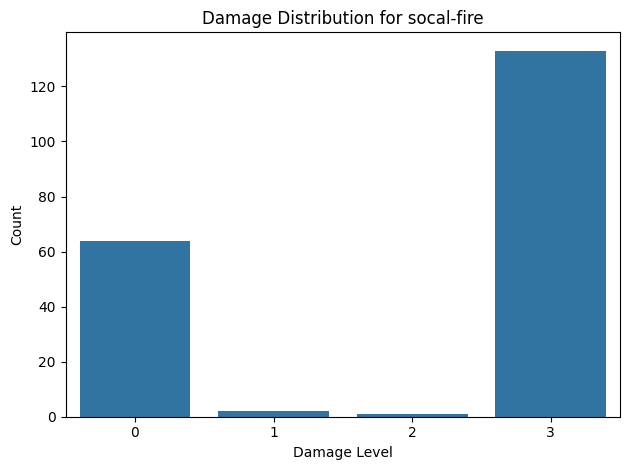

In [8]:
for d in disaster_list:
    damage_counts = pd.Series(data[d]["labels"]).value_counts().sort_index()
    damage_counts.columns = ['Damage Level', 'count']
    plt.figure()
    plt.title(f'Damage Distribution for {d}')
    sns.barplot(damage_counts)
    plt.xlabel('Damage Level')
    plt.ylabel('Count')
    plt.tight_layout()

Graphs show the damage levels of severity of each destruction. Hurricane graphs shows a slight imbalance, while Midwest and Socal Fire show a significant imbalance.

## Distribution of Color (RGB)

In [9]:
def extract_RGB_percentage(image):
    # Extract color channel
    pixels = np.array(image)
    r = pixels[:, :, 0].astype(np.float32)
    g = pixels[:, :, 1].astype(np.float32)
    b = pixels[:, :, 2].astype(np.float32)

    # Sum of all RGB values
    total = r.sum() + g.sum() + b.sum()

    # Calculate percentages
    r_percent = (r.sum() / total) * 100
    g_percent = (g.sum() / total) * 100
    b_percent = (b.sum() / total) * 100
    return r_percent, g_percent, b_percent

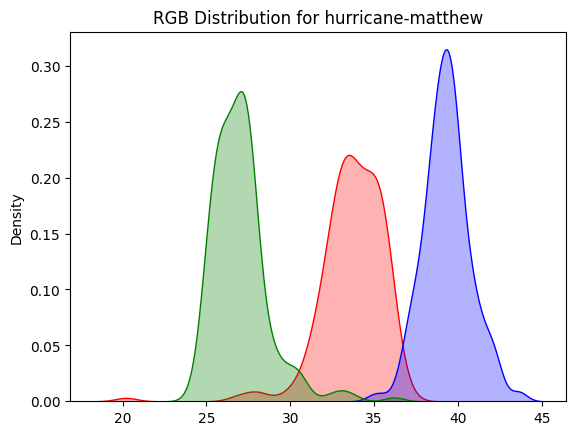

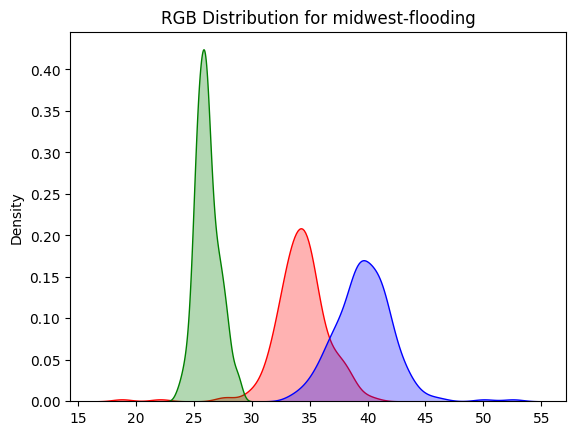

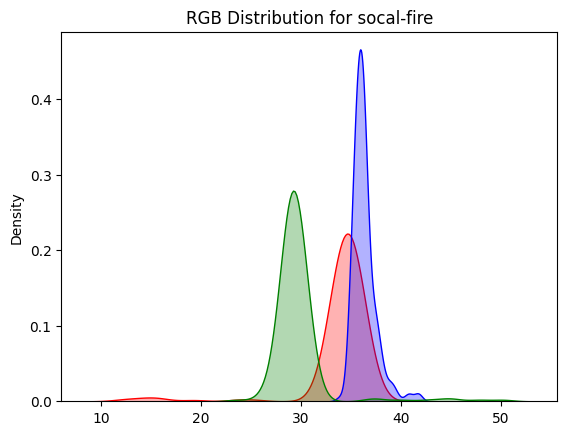

In [10]:
for d in disaster_list:
    rgb_percentage = [extract_RGB_percentage(img) for img in data[d]['images']]
    rgb_df = pd.DataFrame(rgb_percentage)
    rgb_df.columns = ['red', 'blue', 'green']
    plt.figure()
    sns.kdeplot(rgb_df, x='red', fill=True, alpha=0.3, color='red')
    sns.kdeplot(rgb_df, x='blue', fill=True, alpha=0.3, color='blue')
    sns.kdeplot(rgb_df, x='green', fill=True, alpha=0.3, color='green')
    plt.title(f'RGB Distribution for {d}')
    plt.xlabel('')

The graphs are to show the RGB color intensity distributions for each disaster dataset. The hurricane-matthew dataset shows equally distrubted RGB peaks because of diverse surface features and clear color variation across images. midwest-flooding dataset displays lower intensity values and more overlap between the color channels. This means there are more muted tones in areas affected by water and debris. The socal-fire dataset shows more peaks because of fire, smoke, and scorched terrain.

## How are the distributions "separable"?

The below are a non-exhaustive list of ways we can think about classifying these disaster images. You do not have to include all of them in your analysis.

### 1. `midwest-flooding` vs `socal-fire`

Among the different disaster events, are there are distinctions in:

- image height, width, or overall size?
- RGB values?
- Sobel edges?
- Local Binary Patterns?
- Gabor kernels?a

In [ ]:
from feature_utils import get_sobel_features, get_gabor_features, generate_gabor_kernel, get_local_binary_pattern

In [5]:
def extract_sobel_data(data):
    df = pd.DataFrame()
    edges = [get_sobel_features(img) for img in data['images']]
    df['median'] = [np.median(e) for e in edges]
    df['mean'] = [e.mean() for e in edges]
    return df

flood_sobel_df = extract_sobel_data(data['midwest-flooding'])
fire_sobel_df = extract_sobel_data(data['socal-fire'])

<Axes: xlabel='mean', ylabel='Density'>

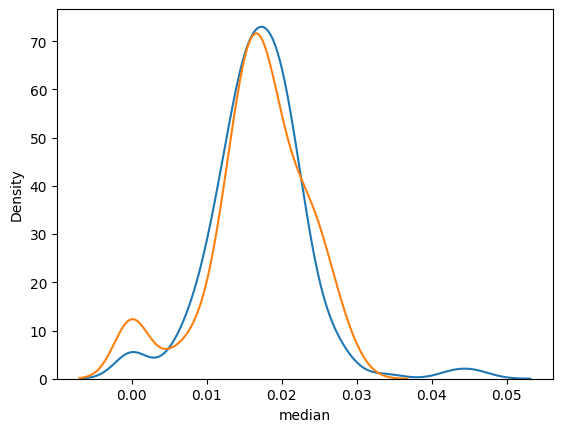

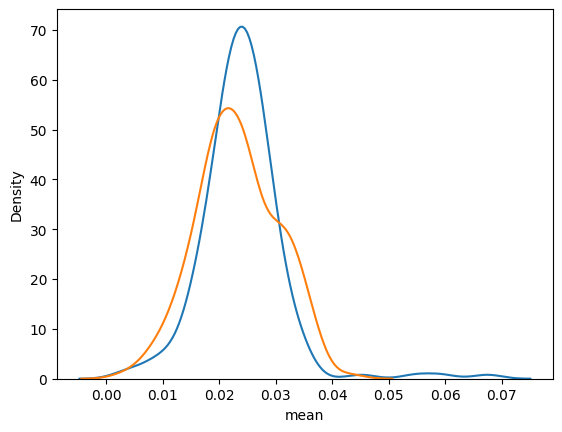

In [6]:
plt.figure()
sns.kdeplot(flood_sobel_df['median'])
sns.kdeplot(fire_sobel_df['median'])

plt.figure()
sns.kdeplot(flood_sobel_df['mean'])
sns.kdeplot(fire_sobel_df['mean'])

The graphs above show the distribution of Sobel edge magnitudes for both median and mean values of midwest-flooding and socal-fire images. Both disasters show similar central tendencies, but socal-fire images show a broader distribution and higher variability. It indicates a stronger contrast and sharper boundaries caused by fire damage.

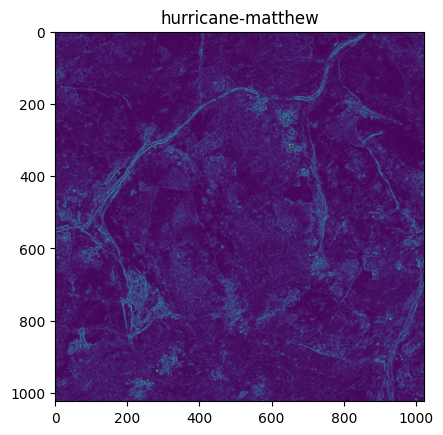

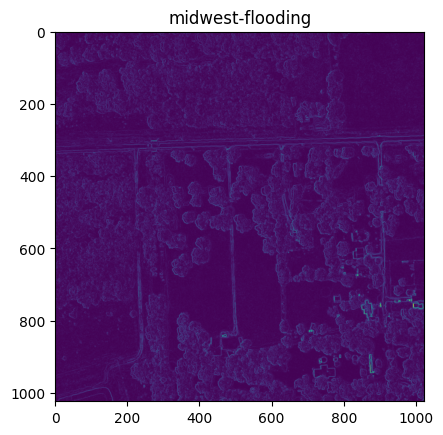

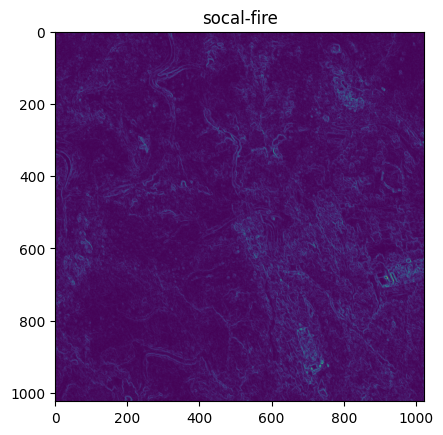

In [7]:
np.random.seed(42)
num_images = 1
for d in disaster_list:
    sample_idx = np.random.choice(range(len(data[d]['images'])), size=num_images)
    for i in sample_idx:
        img = data[d]['images'][i]
        edges = get_sobel_features(img)
        plt.figure()
        plt.title(f'{d}')
        plt.imshow(edges)

The graphs above show sample Sobel edge maps for each disaster dataset. The hurricane-matthew image shows distrubted edge patterns, which is an indication of widespread surface variation. The midwest-flooding image shows more defined and localized edges. socal-fire image shows high-contrast patterns.

In [8]:
theta = 0
sigma = 1.0
frequency = 0.1

kernel = generate_gabor_kernel(theta, sigma, frequency)
def extract_gabor_data(data):
    df = pd.DataFrame()
    edges = [get_gabor_features(img, kernel) for img in data['images']]
    df['median'] = [np.median(e) for e in edges]
    df['mean'] = [e.mean() for e in edges]
    return df

flood_sobel_df = extract_gabor_data(data['midwest-flooding'])
fire_sobel_df = extract_gabor_data(data['socal-fire'])

<Axes: xlabel='mean', ylabel='Density'>

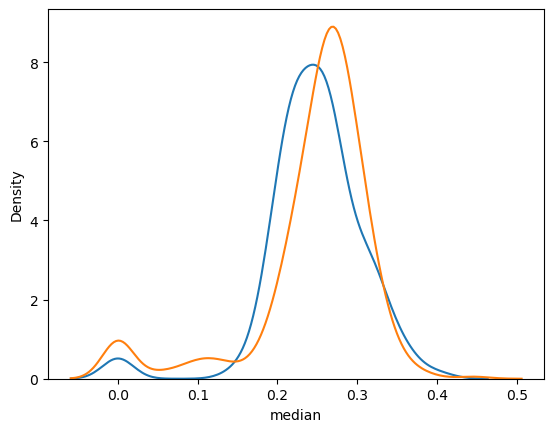

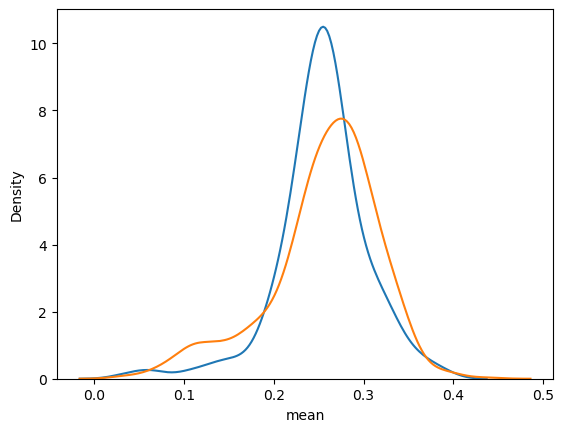

In [ ]:
plt.figure()
sns.kdeplot(flood_sobel_df['median'])
sns.kdeplot(fire_sobel_df['median'])

plt.figure()
sns.kdeplot(flood_sobel_df['mean'])
sns.kdeplot(fire_sobel_df['mean'])

The graphs above show the distributions of the median and mean Gabor for each dataset.

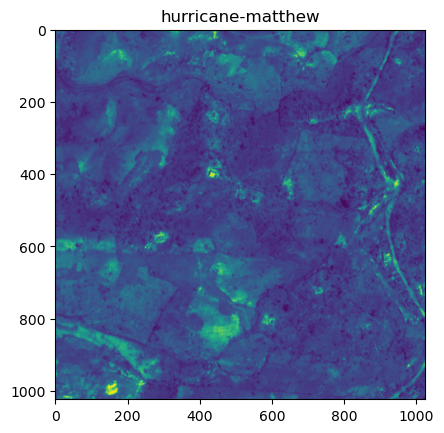

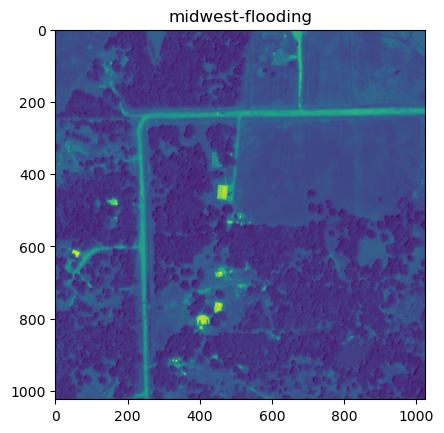

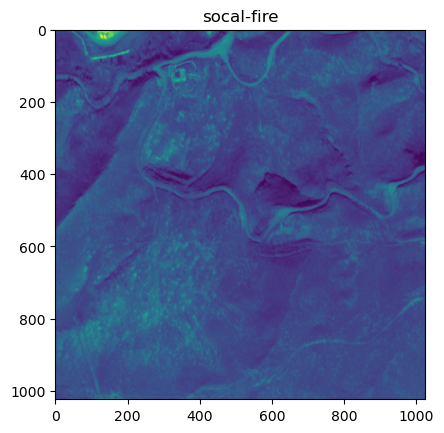

In [ ]:
np.random.seed(42)
num_images = 1
for d in disaster_list:
    sample_idx = np.random.choice(range(len(data[d]['images'])), size=num_images)
    for i in sample_idx:
        img = data[d]['images'][i]
        edges = get_gabor_features(img, kernel)
        plt.figure()
        plt.title(f'{d}')
        plt.imshow(edges)

The figures are for sample Gabor filter responses. The hurricane-matthew visualization shows a textured landscape with variations because of mixed terrain and structural complexity. The midwest-flooding image shows smoother regions because of floodwater coverage. the socal-fire visualization shows linear textures because of the surface damage caused by fire.

In [ ]:
def extract_lbp_data(data):
    df = pd.DataFrame()
    edges = [get_local_binary_pattern(img) for img in data['images']]
    df['median'] = [np.median(e) for e in edges]
    df['mean'] = [e.mean() for e in edges]
    return df

flood_ldp_df = extract_lbp_data(data['midwest-flooding'])
fire_ldp_df = extract_lbp_data(data['socal-fire'])

<Axes: xlabel='mean', ylabel='Density'>

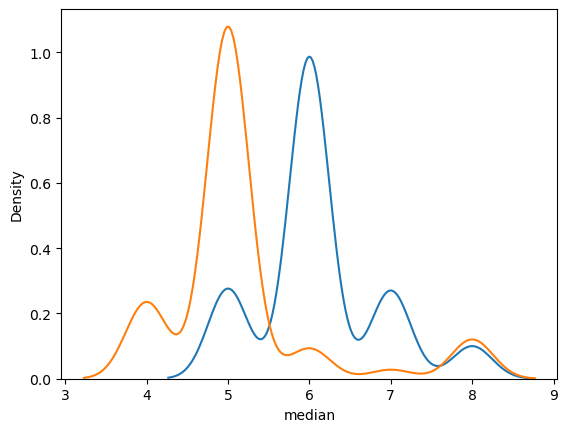

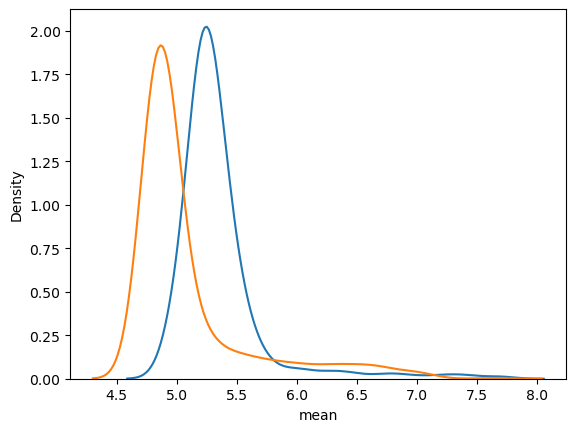

In [ ]:
plt.figure()
sns.kdeplot(flood_ldp_df['median'])
sns.kdeplot(fire_ldp_df['median'])

plt.figure()
sns.kdeplot(flood_ldp_df['mean'])
sns.kdeplot(fire_ldp_df['mean'])

The plots show Local Binary Pattern feature distributions of median and mean values of midwest-flooding and socal-fire.

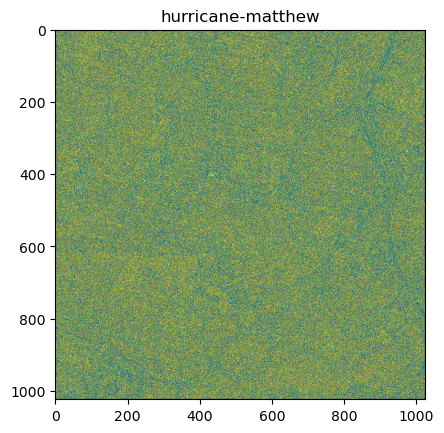

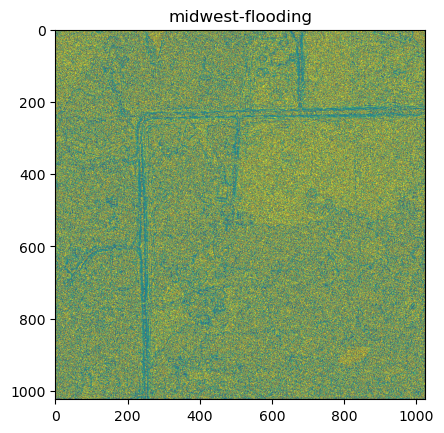

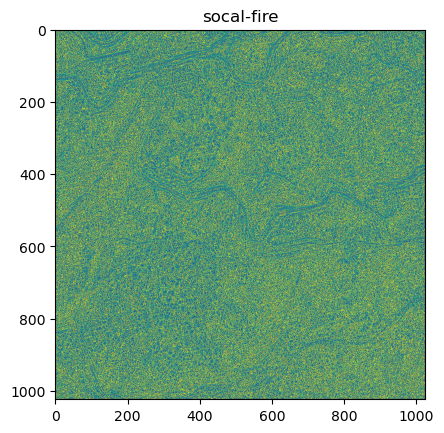

In [ ]:
np.random.seed(42)
num_images = 1
for d in disaster_list:
    sample_idx = np.random.choice(range(len(data[d]['images'])), size=num_images)
    for i in sample_idx:
        img = data[d]['images'][i]
        edges = get_local_binary_pattern(img)
        plt.figure()
        plt.title(f'{d}')
        plt.imshow(edges)

The figures above are for Local Binary Pattern for each disaster. The hurricane-matthew shows a uniform texture with boundaries. The midwest-flooding shows clearer linear and structural patterns because of flooded roads and fields. The socal-fire has wavy textures and higher contrast because of uneven landscape in post-fire regions.

### 2. Damage levels 1 vs 3 within the `hurricane-matthew` dataset

Is there a relationship between the damage level and:

- image height, width, or overall size?
- RGB values?
- Sobel edges?
- Local Binary Patterns?
- Gabor kernels?

Image Size

In [ ]:
hurricane_data = data['hurricane-matthew']

In [ ]:
def get_image_size_info(image):
    return *image.shape[0:2], np.multiply(*image.shape[0:2])

size_df = pd.DataFrame(get_image_size_info(img) for img in hurricane_data['images'])
size_df.columns = ['height', 'width', 'area']
size_df.head(4)

,height,width,area
0,1024,1024,1048576
1,1024,1024,1048576
2,1024,1024,1048576
3,1024,1024,1048576


This table lists the height, width, and area of images in the hurricane-matthew dataset. Images selected share the same dimensions of 1024×1024 pixels.

In [ ]:
rgb_df = pd.DataFrame(extract_RGB_percentage(img) for img in hurricane_data['images'])
rgb_df.columns = ['red percentage', 'blue percentage', 'green percentage']
rgb_df.head(4)

,red percentage,blue percentage,green percentage
0,34.689434,38.089199,27.221367
1,34.380524,40.864803,24.754675
2,35.484436,38.316231,26.199341
3,36.127651,37.605175,26.267174


This table shows the distribution of red, green, and blue color intensities of images from the hurricane-matthew dataset.

In [ ]:
theta = 0
sigma = 1.0
frequency = 0.1

kernel = generate_gabor_kernel(theta, sigma, frequency)

texture_df = pd.DataFrame()
texture_df['sobel mean'] = [get_sobel_features(img).mean() for img in hurricane_data['images']]
texture_df['gabor mean'] = [get_gabor_features(img, kernel).mean() for img in hurricane_data['images']]
texture_df['lbp mean'] = [get_local_binary_pattern(img).mean() for img in hurricane_data['images']]
texture_df.head()

,sobel mean,gabor mean,lbp mean
0,0.018633,0.252758,5.324709
1,0.015331,0.248817,5.322282
2,0.024943,0.325748,4.822704
3,0.027218,0.280044,5.062573
4,0.014778,0.312921,5.024719


This table contains the mean values of Sobel, Gabor, and LBP for each image.

In [ ]:
hurricane_df = pd.concat([rgb_df, size_df, texture_df], axis=1)
hurricane_df['labels'] = hurricane_data['labels']
hurricane_df.head(4)

,red percentage,blue percentage,green percentage,height,width,area,sobel mean,gabor mean,lbp mean,labels
0,34.689434,38.089199,27.221367,1024,1024,1048576,0.018633,0.252758,5.324709,1
1,34.380524,40.864803,24.754675,1024,1024,1048576,0.015331,0.248817,5.322282,3
2,35.484436,38.316231,26.199341,1024,1024,1048576,0.024943,0.325748,4.822704,1
3,36.127651,37.605175,26.267174,1024,1024,1048576,0.027218,0.280044,5.062573,1


This table has all the values combined along with their corresponding class labels.